In [21]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt

In [22]:
pd.set_option('display.max_rows', 500)

In [23]:
passenger_survey_pd = pd.read_csv('./graph_passenger_survey202411.csv')
passenger_survey_pd

,station_en,odpt:surveyYear,P_count,line,station_jp,next_station_en,next_station_jp,sta_long,sta_lat,next_sta_long,next_sta_lat,distance,degree,next_degree,sta_code,next_sta_code
0,Shibuya,2018,3813638,TokyoMetro.Ginza,渋谷,Omote-sando,表参道,139.701017,35.659299,139.711346,35.665652,1.170746,8,5,15,383
1,Shibuya,2018,3813638,Tokyu.DenEnToshi,渋谷,Ikejiriohashi,池尻大橋,139.701017,35.659299,139.683642,35.650526,1.848830,8,2,15,644
2,Shibuya,2018,3813638,Tokyu.Toyoko,渋谷,Daikan-yama,代官山,139.701017,35.659299,139.703084,35.648043,1.265864,8,2,15,1172
3,Shibuya,2018,3813638,TokyoMetro.Hanzomon,渋谷,Omote-sando,表参道,139.701017,35.659299,139.711346,35.665652,1.170746,8,5,15,383
4,Shibuya,2018,3813638,Keio.Inokashira,渋谷,Shinsen,神泉,139.701017,35.659299,139.693130,35.657170,0.751097,8,2,15,728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6982,Futomi,2018,63,JR-East.Uchibo,太海,Awa-Kamogawa,安房鴨川,140.096229,35.081435,140.103566,35.107465,2.971313,2,2,1218,1290
6983,Emi,2020,53,JR-East.Uchibo,江見,Futomi,太海,140.061026,35.062513,140.096229,35.081435,3.834008,2,2,227,1218
6984,Odaka,2016,26,JR-East.Joban,小高,Iwaki-Ota,磐城太田,140.996375,37.562980,140.991407,37.605114,4.706972,2,2,45,0
6985,Namie,2018,24,JR-East.Joban,浪江,Momouchi,桃内,140.989521,37.492291,140.984352,37.528660,4.070946,2,2,83,1179


In [24]:
#build dataframe for node connections, ignoring survey year and passenger numbers for now

# normalize station name casing to fix duplicates like Minami-Senju vs Minami-senju
passenger_survey_pd['station_en'] = passenger_survey_pd['station_en'].str.title()
passenger_survey_pd['next_station_en'] = passenger_survey_pd['next_station_en'].str.title()

station_node_pd = passenger_survey_pd[['line', 'station_en', 'next_station_en', 'distance']].drop_duplicates()
station_node_pd

,line,station_en,next_station_en,distance
0,TokyoMetro.Ginza,Shibuya,Omote-Sando,1.170746
1,Tokyu.DenEnToshi,Shibuya,Ikejiriohashi,1.848830
2,Tokyu.Toyoko,Shibuya,Daikan-Yama,1.265864
3,TokyoMetro.Hanzomon,Shibuya,Omote-Sando,1.170746
4,Keio.Inokashira,Shibuya,Shinsen,0.751097
...,...,...,...,...
6964,Tobu.Sano,Tajima,Sanoshi,2.036123
6967,JR-East.Sotobo,Ubara,Kazusa-Okitsu,2.575892
6971,JR-East.Uchibo,Futomi,Awa-Kamogawa,2.971313
6980,Tobu.Nikko,Itaga,Shimo-Goshiro,3.569833


In [25]:
# build graph structure using networkx
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_en', 'next_station_en', edge_attr=True)

print(G["Shibuya"]["Shinsen"])

{'line': 'Keio.Inokashira', 'distance': 0.7510969855036685}


(<Figure size 480x480 with 1 Axes>, <Axes: >)

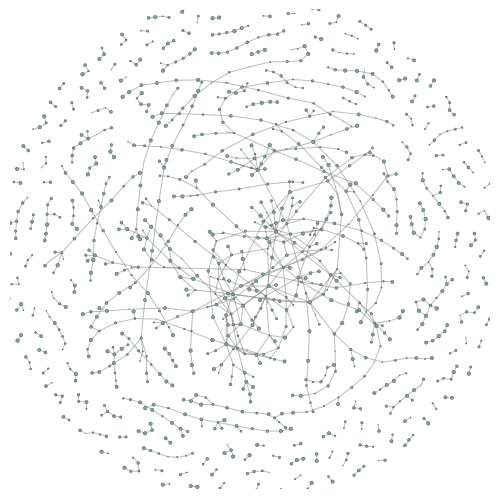

In [26]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)

In [69]:
print(stylized_network['links'][0])

{'source': 'Shibuya', 'target': 'Omote-sando', 'width': 1.5, 'weight': 1}


In [70]:
#normalize distances
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))
station_node_pd

,line,station_en,next_station_en,distance,nor_distance
0,TokyoMetro.Ginza,Shibuya,Omote-sando,1.170746,0.047560
1,Tokyu.DenEnToshi,Shibuya,Ikejiriohashi,1.848830,0.077679
2,Tokyu.Toyoko,Shibuya,Daikan-yama,1.265864,0.051785
3,TokyoMetro.Hanzomon,Shibuya,Omote-sando,1.170746,0.047560
4,Keio.Inokashira,Shibuya,Shinsen,0.751097,0.028920
...,...,...,...,...,...
6964,Tobu.Sano,Tajima,Sanoshi,2.036123,0.085998
6967,JR-East.Sotobo,Ubara,Kazusa-Okitsu,2.575892,0.109973
6971,JR-East.Uchibo,Futomi,Awa-Kamogawa,2.971313,0.127537
6980,Tobu.Nikko,Itaga,Shimo-goshiro,3.569833,0.154121


In [71]:
#get operator name from line name
#TODO this could be redundant, could just directly get operator instead
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_en,next_station_en,distance,nor_distance,operator
0,TokyoMetro.Ginza,Shibuya,Omote-sando,1.170746,0.047560,TokyoMetro
1,Tokyu.DenEnToshi,Shibuya,Ikejiriohashi,1.848830,0.077679,Tokyu
2,Tokyu.Toyoko,Shibuya,Daikan-yama,1.265864,0.051785,Tokyu
3,TokyoMetro.Hanzomon,Shibuya,Omote-sando,1.170746,0.047560,TokyoMetro
4,Keio.Inokashira,Shibuya,Shinsen,0.751097,0.028920,Keio
...,...,...,...,...,...,...
6964,Tobu.Sano,Tajima,Sanoshi,2.036123,0.085998,Tobu
6967,JR-East.Sotobo,Ubara,Kazusa-Okitsu,2.575892,0.109973,JR-East
6971,JR-East.Uchibo,Futomi,Awa-Kamogawa,2.971313,0.127537,JR-East
6980,Tobu.Nikko,Itaga,Shimo-goshiro,3.569833,0.154121,Tobu


In [72]:
#let's color lines by operator

operators_list = station_node_pd['operator'].unique()
operators_list.sort()
print("Operators:", operators_list)

colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

Operators: ['JR-East' 'Keikyu' 'Keio' 'Seibu' 'Sotetsu' 'TWR' 'Tobu' 'Toei'
 'TokyoMetro' 'Tokyu' 'YokohamaMunicipal' 'Yurikamome']


{'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Seibu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'Sotetsu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'TWR': (0.7019607843137254, 0.8705882352941177, 0.4117647058823529, 1.0),
 'Tobu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Toei': (0.5019607843137255, 0.6941176470588235, 0.8274509803921568, 1.0),
 'TokyoMetro': (0.984313725490196,
  0.5019607843137255,
  0.4470588235294118,
  1.0),
 'Tokyu': (0.7450980392156863, 0.7294117647058823, 0.8549019607843137, 1.0),
 'YokohamaMunicipal': (1.0, 1.0, 0.7019607843137254, 1.0),
 'Yurikamome': (0.5529411764705883,
  0.8274509803921568,
  0.7803921568627451,
  1.0)}

In [73]:
for link in stylized_network['links']:
    
    line = station_node_pd[((station_node_pd['station_en'] == link['source']) & (station_node_pd['next_station_en'] == link['target'])) |
                           ((station_node_pd['station_en'] == link['target']) & (station_node_pd['next_station_en'] == link['source']))]
    # print(line)
    if len(line) > 0:
        print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]] # 0 takes the first row and 5 takes the operator column. this is fine since if multiple lines go between two stations just pick one of them for the color
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
    else:
        print(link)
        # if didn't print link, then all the lines have been found

                  line station_en next_station_en  distance  nor_distance  \
0     TokyoMetro.Ginza    Shibuya     Omote-sando  1.170746       0.04756   
3  TokyoMetro.Hanzomon    Shibuya     Omote-sando  1.170746       0.04756   

     operator  
0  TokyoMetro  
3  TokyoMetro  
               line station_en next_station_en  distance  nor_distance  \
1  Tokyu.DenEnToshi    Shibuya   Ikejiriohashi   1.84883      0.077679   

  operator  
1    Tokyu  
           line station_en next_station_en  distance  nor_distance operator
2  Tokyu.Toyoko    Shibuya     Daikan-yama  1.265864      0.051785    Tokyu
              line station_en next_station_en  distance  nor_distance operator
4  Keio.Inokashira    Shibuya         Shinsen  0.751097       0.02892     Keio
                     line station_en next_station_en  distance  nor_distance  \
5   JR-East.SaikyoKawagoe    Shibuya        Shinjuku  3.248816      0.139863   
6  JR-East.ShonanShinjuku    Shibuya        Shinjuku  3.248816      0.13986

In [74]:
for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_en'] == node['id']] #node id is station name in english
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 5]]
        if sta['P_count'].mean() < 10000:
            node['radius'] = 1.5
        elif sta['P_count'].mean() < 100000:
            node['radius'] = 2.5
        elif sta['P_count'].mean() < 500000:
            node['radius'] = 4
        elif sta['P_count'].mean() < 1000000:
            node['radius'] = 7
        elif sta['P_count'].mean() < 2000000:
            node['radius'] = 9
        else:
            node['radius'] = 10
    else:
        print("station not found in survey data:", node['id'])
    # highlight major stations in green
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

station not found in survey data: Omote-sando
station not found in survey data: Daikan-yama
station not found in survey data: Shinjuku-sanchome
station not found in survey data: Shin-Okubo
station not found in survey data: Higashi-ikebukuro
station not found in survey data: Kita-ikebukuro
station not found in survey data: Mitsuzawa-Shimocho
station not found in survey data: Shin-Kawasaki
station not found in survey data: Shimo-Ochiai
station not found in survey data: Shin-Nihombashi
station not found in survey data: Higashi-ginza
station not found in survey data: Fudo-mae
station not found in survey data: Nishi-Oi
station not found in survey data: Shin-ochanomizu
station not found in survey data: Kita-ayase
station not found in survey data: Naka-okachimachi
station not found in survey data: Ginza-itchome
station not found in survey data: Shimo-shimmei
station not found in survey data: Kita-omiya
station not found in survey data: Saitama-Shintoshin
station not found in survey data: Nish

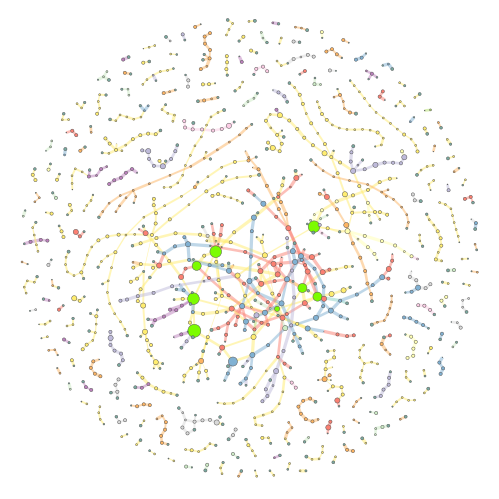

In [75]:
# Plot the modified stylized_network (don't re-create from G, that would discard all changes)
fig, ax = nw.draw_netwulf(stylized_network, config)
plt.show()

In [78]:
print("number of edges:", len(stylized_network['links']))
print("number of nodes:", len(stylized_network['nodes']))
print("passenger count means for stations with more than 500k passengers:")
for sta in passenger_survey_pd[passenger_survey_pd['P_count'] > 500000].groupby(by='station_en'):
    print(sta[0] + ': {}'.format(sta[1]['P_count'].mean()))

number of edges: 1018
number of nodes: 1158
passenger count means for stations with more than 500k passengers:
Ikebukuro: 1574140.375
Meguro: 619188.3333333334
Shibuya: 3392235.625
Shimbashi: 583241.2
Shinagawa: 524169.0
Shinjuku: 1617659.375
Takadanobaba: 702770.7142857143
Tokyo: 643634.7142857143
Yokohama: 1027686.75


In [ ]:
#test:

# Create a network
test_G = nx.random_partition_graph([10, 10, 10], .25, .01)

# Change 'block' node attribute to 'group'
for k, v in test_G.nodes(data=True):
    v['group'] = v['block']; del v['block']

# Or detect communities and encode them in 'group' attribute
# import community
# bb = community.best_partition(G)
# nx.set_node_attributes(G, bb, 'group')

# Set node 'size' attributes
for n, data in test_G.nodes(data=True):
    data['size'] = np.random.random()

# Set link 'weight' attributes
for n1, n2, data in test_G.edges(data=True):
    data['weight'] = np.random.random()

test_return, test_config = nw.visualize(test_G)

sta 64
Shibuya {'group': (0.984313725490196, 0.5019607843137255, 0.4470588235294118, 1.0), 'size': 10}
sta 0
sta 8
sta 0
sta 5
sta 80
sta 8
sta 8
sta 0
sta 5
sta 5
sta 24
sta 7
sta 56
sta 0
sta 8
sta 0
sta 0
sta 8
sta 8
sta 40
sta 8
sta 56
sta 2
sta 3
sta 0
sta 16
sta 0
sta 32
sta 16
sta 24
sta 8
sta 0
sta 8
sta 88
sta 40
sta 32
sta 56
sta 24
sta 16
sta 0
sta 64
sta 0
sta 24
sta 8
sta 16
sta 48
sta 32
sta 16
sta 0
sta 32
sta 2
sta 24
sta 24
sta 24
sta 0
sta 24
sta 0
sta 16
sta 8
sta 24
sta 16
sta 0
sta 8
sta 32
sta 0
sta 24
sta 8
sta 16
sta 32
sta 16
sta 16
sta 16
sta 24
sta 0
sta 24
sta 4
sta 8
sta 8
sta 8
sta 40
sta 8
sta 16
sta 24
sta 32
sta 8
sta 8
sta 32
sta 8
sta 16
sta 16
sta 16
sta 8
sta 0
sta 8
sta 16
sta 8
sta 40
sta 0
sta 0
sta 8
sta 8
sta 8
sta 8
sta 8
sta 0
sta 8
sta 16
sta 0
sta 8
sta 24
sta 0
sta 1
sta 8
sta 4
sta 16
sta 0
sta 8
sta 24
sta 8
sta 0
sta 0
sta 8
sta 8
sta 0
sta 8
sta 4
sta 8
sta 8
sta 16
sta 8
sta 8
sta 24
sta 0
sta 16
sta 0
sta 16
sta 8
sta 8
sta 8
sta 24


(<Figure size 480x480 with 1 Axes>, <Axes: >)

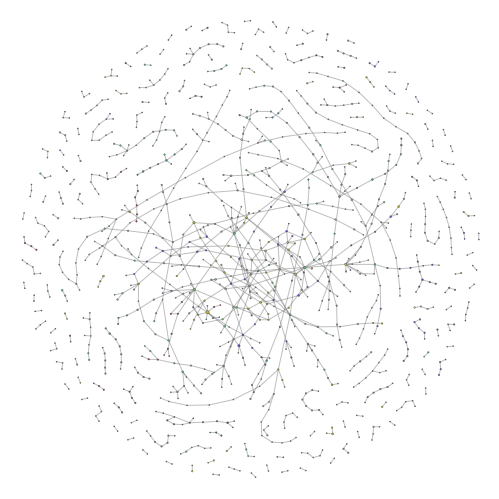

In [ ]:
test_G = nx.Graph()
test_G = nx.from_pandas_edgelist(station_node_pd, 'station_en', 'next_station_en', edge_attr=True)

for k, v in test_G.nodes(data=True):
    v['group'] = line_color[station_node_pd[(station_node_pd['station_en'] == k) | (station_node_pd['next_station_en'] == k)].iloc[0, 5]]

for n, data in test_G.nodes(data=True):
    sta = passenger_survey_pd[passenger_survey_pd['station_en'] == n]
    if len(sta) > 0:
        if sta['P_count'].mean() < 10000:
            data['size'] = 1
        elif sta['P_count'].mean() < 100000:
            data['size'] = 2
        elif sta['P_count'].mean() < 500000:
            data['size'] = 3
        else:
            data['size'] = 5
    else:
        data['size'] = 1
    if n == 'Shibuya':
        data['size'] = 10
        print(n, data)
test_return, test_config = nw.visualize(test_G, plot_in_cell_below=True)
nw.draw_netwulf(test_return, test_config)


# print(test_G.edges(data=True))